Saving Customer-Churn.csv to Customer-Churn.csv
Dataset Shape: (7043, 21)

First 5 Rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No

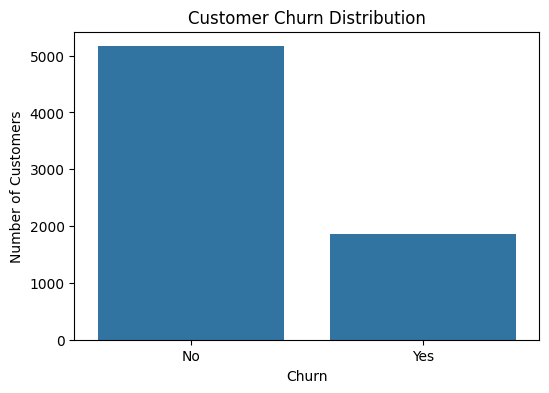


Gender Distribution:
gender
Male      3549
Female    3483
Name: count, dtype: int64


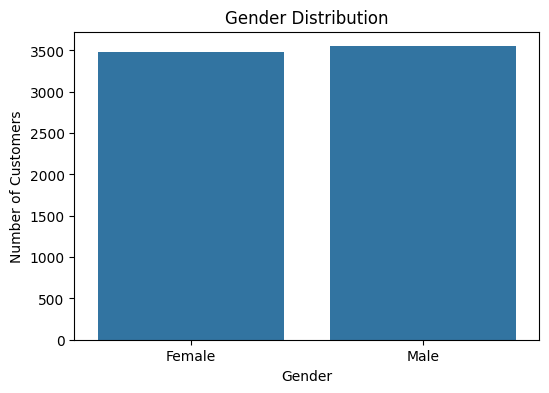


Contract Type Distribution:
Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64


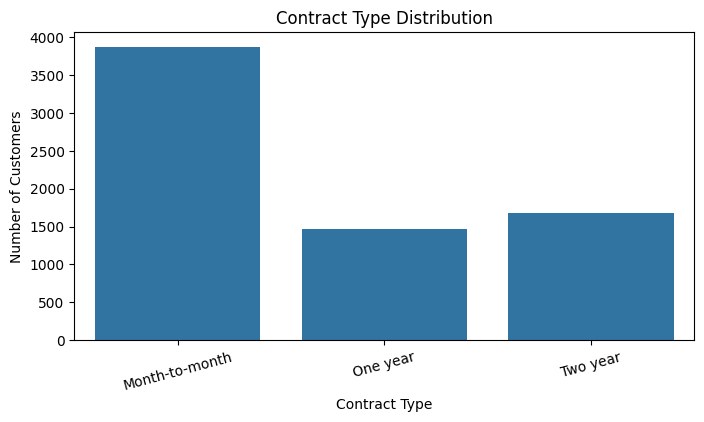


Payment Method Distribution:
PaymentMethod
Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: count, dtype: int64


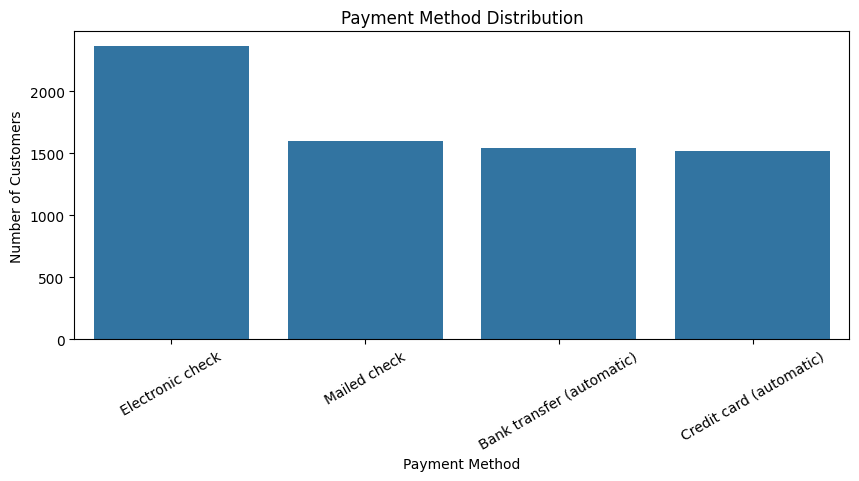

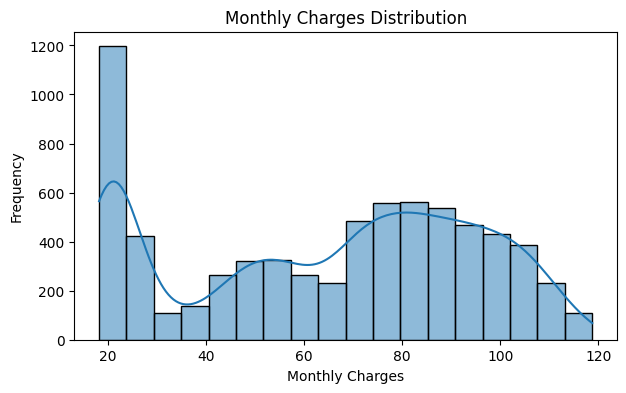

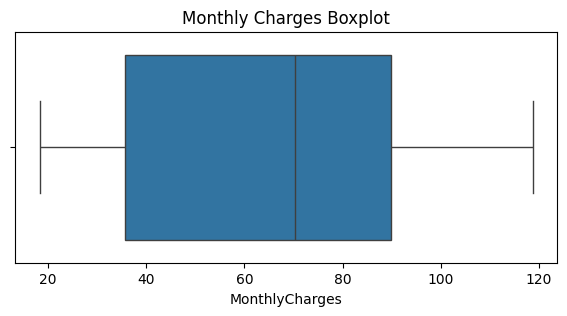

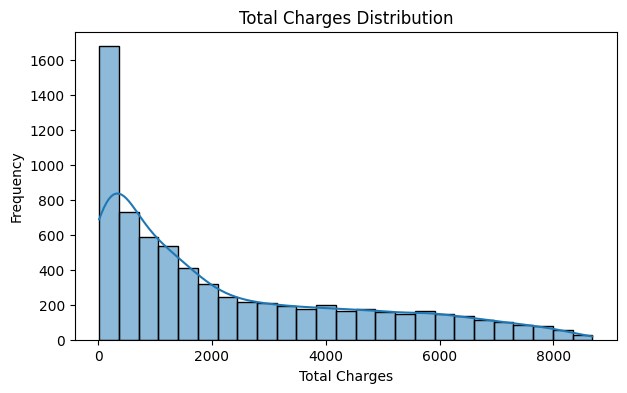

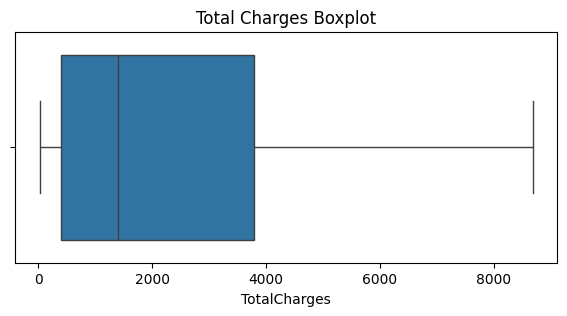

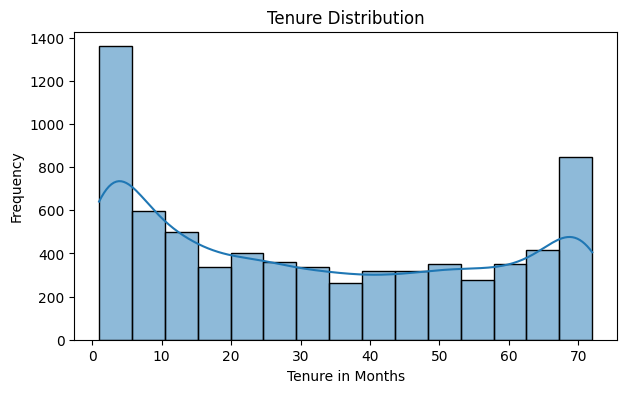

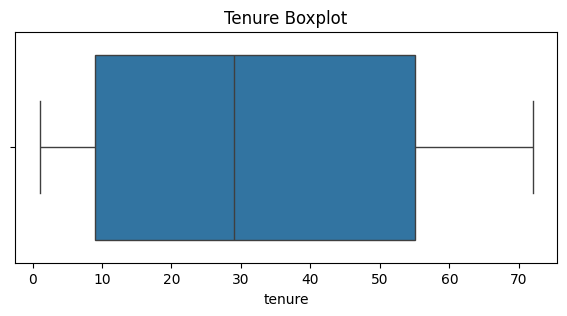


IQR Outlier Detection:

Feature: MonthlyCharges
Q1: 35.5875
Q3: 89.8625
IQR: 54.275
Lower Bound: -45.824999999999996
Upper Bound: 171.27499999999998
Number of Outliers: 0

Feature: TotalCharges
Q1: 401.45
Q3: 3794.7375
IQR: 3393.2875000000004
Lower Bound: -4688.481250000001
Upper Bound: 8884.66875
Number of Outliers: 0

Feature: tenure
Q1: 9.0
Q3: 55.0
IQR: 46.0
Lower Bound: -60.0
Upper Bound: 124.0
Number of Outliers: 0


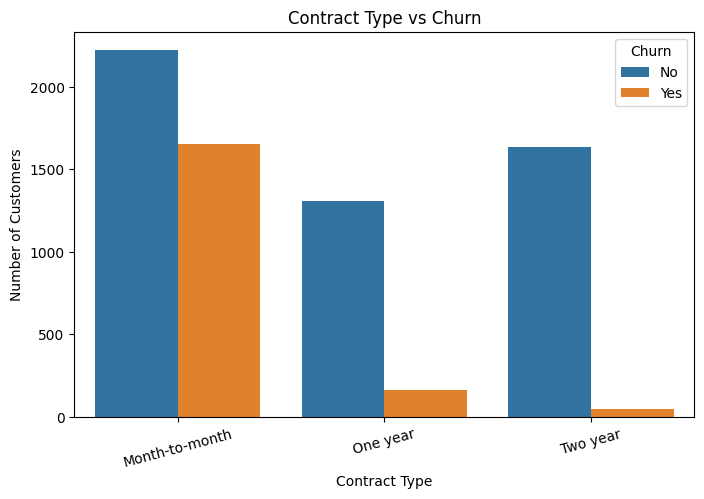


Contract Type vs Churn Percentage:
Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.722826  11.277174
Two year        97.151335   2.848665


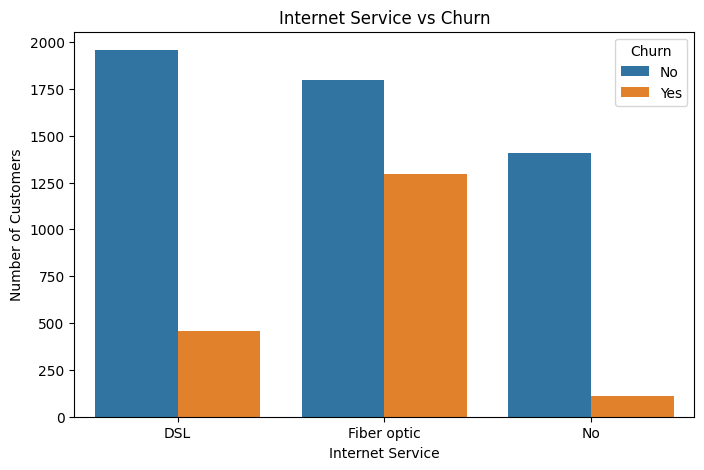


Internet Service vs Churn Percentage:
Churn                   No        Yes
InternetService                      
DSL              81.001656  18.998344
Fiber optic      58.107235  41.892765
No               92.565789   7.434211


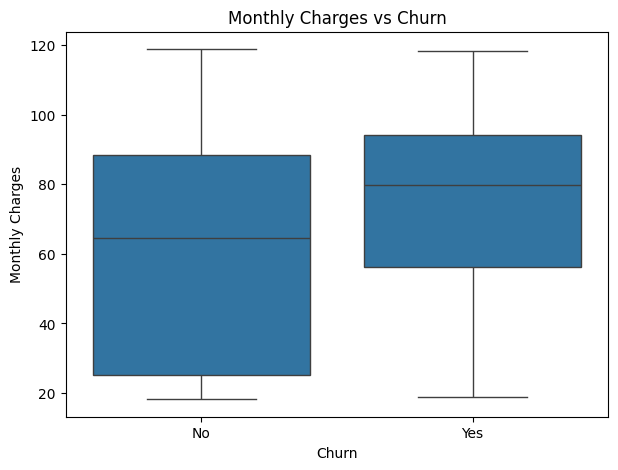

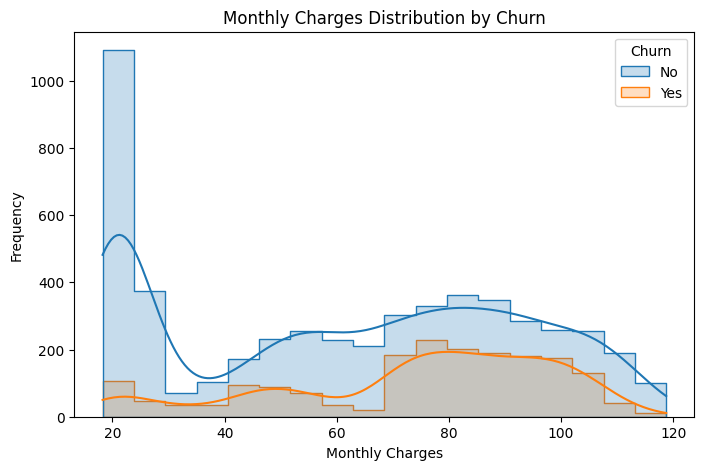

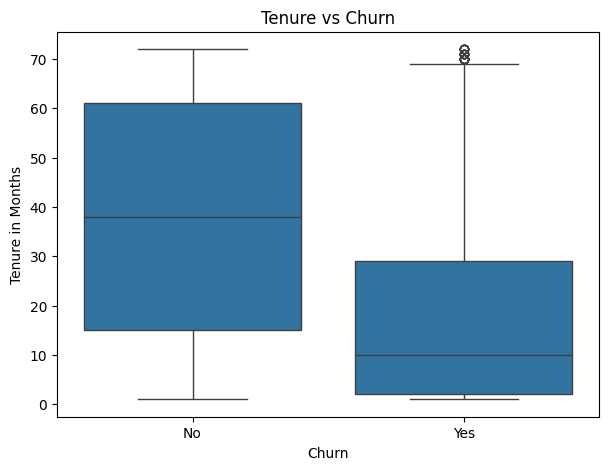


Average Tenure by Churn:
Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64

Median Tenure by Churn:
Churn
No     38.0
Yes    10.0
Name: tenure, dtype: float64

Churn Rate by Contract:
Contract
Month-to-month    42.709677
One year          11.277174
Two year           2.848665
Name: Churn, dtype: float64

Contract Type with Highest Churn:
Month-to-month

Payment Methods Used by Churned Customers:
PaymentMethod
Electronic check             1071
Mailed check                  308
Bank transfer (automatic)     258
Credit card (automatic)       232
Name: count, dtype: int64

Most Frequently Used Payment Method by Churned Customers:
Electronic check

Average Tenure by Churn:
Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64

Average Monthly Charges by Contract:
Contract
Month-to-month    66.398490
One year          65.079416
Two year          60.872374
Name: MonthlyCharges, dtype: float64

Average Monthly Charges by Internet Service:
InternetService
Fibe

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

uploaded = files.upload()

df = pd.read_csv("Customer-Churn.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
print(df.describe(include='all'))

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("\nMissing Values After Converting TotalCharges:")
print(df.isnull().sum())

df = df.dropna()

if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

    print("\nCleaned Dataset Shape:", df.shape)

    print("\nCustomer Churn Distribution:")
    print(df['Churn'].value_counts())

    print("\nCustomer Churn Percentage:")
    print(df['Churn'].value_counts(normalize=True) * 100)

    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x='Churn')
    plt.title('Customer Churn Distribution')
    plt.xlabel('Churn')
    plt.ylabel('Number of Customers')
    plt.show()

    print("\nGender Distribution:")
    print(df['gender'].value_counts())

    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x='gender')
    plt.title('Gender Distribution')
    plt.xlabel('Gender')
    plt.ylabel('Number of Customers')
    plt.show()

    print("\nContract Type Distribution:")
    print(df['Contract'].value_counts())

    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x='Contract')
    plt.title('Contract Type Distribution')
    plt.xlabel('Contract Type')
    plt.ylabel('Number of Customers')
    plt.xticks(rotation=15)
    plt.show()

    print("\nPayment Method Distribution:")
    print(df['PaymentMethod'].value_counts())

    plt.figure(figsize=(10,4))
    sns.countplot(data=df, x='PaymentMethod')
    plt.title('Payment Method Distribution')
    plt.xlabel('Payment Method')
    plt.ylabel('Number of Customers')
    plt.xticks(rotation=30)
    plt.show()

    plt.figure(figsize=(7,4))
    sns.histplot(data=df, x='MonthlyCharges', kde=True)
    plt.title('Monthly Charges Distribution')
    plt.xlabel('Monthly Charges')
    plt.ylabel('Frequency')
    plt.show()

    plt.figure(figsize=(7,3))
    sns.boxplot(x=df['MonthlyCharges'])
    plt.title('Monthly Charges Boxplot')
    plt.show()

    plt.figure(figsize=(7,4))
    sns.histplot(data=df, x='TotalCharges', kde=True)
    plt.title('Total Charges Distribution')
    plt.xlabel('Total Charges')
    plt.ylabel('Frequency')
    plt.show()

    plt.figure(figsize=(7,3))
    sns.boxplot(x=df['TotalCharges'])
    plt.title('Total Charges Boxplot')
    plt.show()

    plt.figure(figsize=(7,4))
    sns.histplot(data=df, x='tenure', kde=True)
    plt.title('Tenure Distribution')
    plt.xlabel('Tenure in Months')
    plt.ylabel('Frequency')
    plt.show()

    plt.figure(figsize=(7,3))
    sns.boxplot(x=df['tenure'])
    plt.title('Tenure Boxplot')
    plt.show()

    numerical_features = ['MonthlyCharges', 'TotalCharges', 'tenure']

    print("\nIQR Outlier Detection:")

    for column in numerical_features:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

        print("\nFeature:", column)
        print("Q1:", Q1)
        print("Q3:", Q3)
        print("IQR:", IQR)
        print("Lower Bound:", lower_bound)
        print("Upper Bound:", upper_bound)
        print("Number of Outliers:", len(outliers))

    plt.figure(figsize=(8,5))
    sns.countplot(data=df, x='Contract', hue='Churn')
    plt.title('Contract Type vs Churn')
    plt.xlabel('Contract Type')
    plt.ylabel('Number of Customers')
    plt.xticks(rotation=15)
    plt.show()

    contract_churn = pd.crosstab(
        df['Contract'],
        df['Churn'],
        normalize='index'
        ) * 100

    print("\nContract Type vs Churn Percentage:")
    print(contract_churn)

    plt.figure(figsize=(8,5))
    sns.countplot(data=df, x='InternetService', hue='Churn')
    plt.title('Internet Service vs Churn')
    plt.xlabel('Internet Service')
    plt.ylabel('Number of Customers')
    plt.show()

    internet_churn = pd.crosstab(
        df['InternetService'],
        df['Churn'],
        normalize='index'
        ) * 100

    print("\nInternet Service vs Churn Percentage:")
    print(internet_churn)

    plt.figure(figsize=(7,5))
    sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
    plt.title('Monthly Charges vs Churn')
    plt.xlabel('Churn')
    plt.ylabel('Monthly Charges')
    plt.show()

    plt.figure(figsize=(8,5))
    sns.histplot(
        data=df,
        x='MonthlyCharges',
        hue='Churn',
        kde=True,
        element='step'
        )
    plt.title('Monthly Charges Distribution by Churn')
    plt.xlabel('Monthly Charges')
    plt.ylabel('Frequency')
    plt.show()

    plt.figure(figsize=(7,5))
    sns.boxplot(data=df, x='Churn', y='tenure')
    plt.title('Tenure vs Churn')
    plt.xlabel('Churn')
    plt.ylabel('Tenure in Months')
    plt.show()

    print("\nAverage Tenure by Churn:")
    print(df.groupby('Churn')['tenure'].mean())

    print("\nMedian Tenure by Churn:")
    print(df.groupby('Churn')['tenure'].median())

    contract_churn_rate = df.groupby('Contract')['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100
        )

    print("\nChurn Rate by Contract:")
    print(contract_churn_rate)

    print("\nContract Type with Highest Churn:")
    print(contract_churn_rate.idxmax())

    churned = df[df['Churn'] == 'Yes']

    payment_churn = churned['PaymentMethod'].value_counts()

    print("\nPayment Methods Used by Churned Customers:")
    print(payment_churn)

    print("\nMost Frequently Used Payment Method by Churned Customers:")
    print(payment_churn.idxmax())

    print("\nAverage Tenure by Churn:")
    print(df.groupby('Churn')['tenure'].mean())

    print("\nAverage Monthly Charges by Contract:")
    print(
        df.groupby('Contract')['MonthlyCharges']
            .mean()
            .sort_values(ascending=False)
            )

    print("\nAverage Monthly Charges by Internet Service:")
    print(
        df.groupby('InternetService')['MonthlyCharges']
            .mean()
            .sort_values(ascending=False)
            )

    internet_churn_rate = df.groupby('InternetService')['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100
        )

    print("\nChurn Rate by Internet Service:")
    print(internet_churn_rate)

    print("\nInternet Service with Highest Churn:")
    print(internet_churn_rate.idxmax())

    print("\nAverage Monthly Charges by Churn:")
    print(df.groupby('Churn')['MonthlyCharges'].mean())

    print("\nMedian Monthly Charges by Churn:")
    print(df.groupby('Churn')['MonthlyCharges'].median())

    features = [
        'Contract',
        'InternetService',
        'PaymentMethod',
        'OnlineSecurity',
        'TechSupport',
        'PaperlessBilling'
        ]

    print("\nCategorical Features and Churn Rates:")

    for feature in features:
        print("\n", feature)
        result = df.groupby(feature)['Churn'].apply(
            lambda x: (x == 'Yes').mean() * 100
            ).sort_values(ascending=False)
        print(result)

    print("\nNumerical Features by Churn:")
    print(
        df.groupby('Churn')[
            ['tenure', 'MonthlyCharges', 'TotalCharges']
            ].mean()
            )

    X = df.drop('Churn', axis=1)
    y = df['Churn']

    y = y.map({'No': 0, 'Yes': 1})

    X = pd.get_dummies(X, drop_first=True)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
        )

    print("\nTraining Data Shape:")
    print(X_train.shape)

    print("\nTesting Data Shape:")
    print(X_test.shape)

    print("\nTraining Target Shape:")
    print(y_train.shape)

    print("\nTesting Target Shape:")
    print(y_test.shape)

    processed_df = X.copy()
    processed_df['Churn'] = y

    processed_df.to_csv(
        'CustomerChurn_Preprocessed.csv',
        index=False
        )

    final_df = pd.read_csv('CustomerChurn_Preprocessed.csv')

    print("\nFinal Dataset Shape:")
    print(final_df.shape)

    print("\nFinal Dataset:")
    print(final_df.head())

    print("\nTotal Missing Values:")
    print(final_df.isnull().sum().sum())

    print("\nFinal File Created Successfully:")
    print("CustomerChurn_Preprocessed.csv")

    files.download('CustomerChurn_Preprocessed.csv')
